In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from scipy.stats import f_oneway

sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File:", file_name)
print("Shape:", df.shape)

display(df.head())

Saving hospital_resource_allocation_practical_dataset.csv to hospital_resource_allocation_practical_dataset.csv
Dataset loaded successfully!
File: hospital_resource_allocation_practical_dataset.csv
Shape: (120, 8)


,Month,Department,Patient_Volume,Average_Treatment_Duration,Staff_Count,Equipment_Utilisation,Workload_Pressure,Resource_Status
0,2025-01,Emergency,4385,1.35,53.0,85.6,111.69,Normal
1,2025-01,General Medicine,2349,2.67,42.0,70.0,149.33,Moderate
2,2025-01,Cardiology,1287,4.07,33.0,80.9,158.73,Moderate
3,2025-01,Orthopedics,1498,3.74,35.0,73.0,160.07,Moderate
4,2025-01,Pediatrics,1937,2.13,37.0,68.7,111.51,Normal


In [ ]:
required_columns = [
    "Month",
    "Department",
    "Patient_Volume",
    "Average_Treatment_Duration",
    "Staff_Count",
    "Equipment_Utilisation",
    "Resource_Status"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are present.")

All required columns are present.


In [ ]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDepartments:")
print(df["Department"].unique())

print("\nResource Status:")
display(df["Resource_Status"].value_counts())

Dataset Shape: (120, 8)

Data Types:
Month                          object
Department                     object
Patient_Volume                  int64
Average_Treatment_Duration    float64
Staff_Count                   float64
Equipment_Utilisation         float64
Workload_Pressure             float64
Resource_Status                object
dtype: object

Missing Values:


,Missing Values
Month,0
Department,0
Patient_Volume,0
Average_Treatment_Duration,2
Staff_Count,1
Equipment_Utilisation,2
Workload_Pressure,0
Resource_Status,0



Duplicate Rows:
0

Departments:
['Emergency' 'General Medicine' 'Cardiology' 'Orthopedics' 'Pediatrics'
 'Neurology' 'Obstetrics' 'Oncology' 'ENT' 'Dermatology']

Resource Status:


,count
Resource_Status,
Normal,66
Moderate,32
High,22


In [ ]:
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Convert Month
df_clean["Month"] = pd.to_datetime(
    df_clean["Month"],
    format="%Y-%m"
)

# Numeric columns
numeric_columns = [
    "Patient_Volume",
    "Average_Treatment_Duration",
    "Staff_Count",
    "Equipment_Utilisation"
]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )

# Fill missing numeric values using department median
for col in numeric_columns:
    df_clean[col] = df_clean.groupby(
        "Department"
    )[col].transform(
        lambda x: x.fillna(x.median())
    )

# If anything is still missing, use overall median
for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

# Limit utilisation to valid percentage range
df_clean["Equipment_Utilisation"] = (
    df_clean["Equipment_Utilisation"].clip(0, 100)
)

# Limit staff and patient values
df_clean["Patient_Volume"] = (
    df_clean["Patient_Volume"].clip(lower=0)
)

df_clean["Staff_Count"] = (
    df_clean["Staff_Count"].clip(lower=1)
)

print("Cleaned dataset shape:", df_clean.shape)

print("\nRemaining missing values:")
display(df_clean.isnull().sum())

Cleaned dataset shape: (120, 8)

Remaining missing values:


,0
Month,0
Department,0
Patient_Volume,0
Average_Treatment_Duration,0
Staff_Count,0
Equipment_Utilisation,0
Workload_Pressure,0
Resource_Status,0


In [ ]:
# Month number
df_clean["Month_Number"] = (
    df_clean["Month"].dt.month
)

# Month name
df_clean["Month_Name"] = (
    df_clean["Month"].dt.strftime("%B")
)

# Treatment workload
df_clean["Treatment_Workload"] = (
    df_clean["Patient_Volume"]
    * df_clean["Average_Treatment_Duration"]
)

# Staff-to-patient ratio
df_clean["Staff_to_Patient_Ratio"] = (
    df_clean["Staff_Count"]
    / df_clean["Patient_Volume"]
    * 100
)

# Patients per staff member
df_clean["Patients_Per_Staff"] = (
    df_clean["Patient_Volume"]
    / df_clean["Staff_Count"]
)

# Workload pressure
df_clean["Workload_Pressure_Calculated"] = (
    df_clean["Treatment_Workload"]
    / df_clean["Staff_Count"]
)

display(
    df_clean[
        [
            "Department",
            "Patient_Volume",
            "Average_Treatment_Duration",
            "Staff_Count",
            "Treatment_Workload",
            "Staff_to_Patient_Ratio",
            "Patients_Per_Staff",
            "Workload_Pressure_Calculated"
        ]
    ].head(10)
)

,Department,Patient_Volume,Average_Treatment_Duration,Staff_Count,Treatment_Workload,Staff_to_Patient_Ratio,Patients_Per_Staff,Workload_Pressure_Calculated
0,Emergency,4385,1.35,53.0,5919.75,1.208666,82.735849,111.693396
1,General Medicine,2349,2.67,42.0,6271.83,1.787995,55.928571,149.329286
2,Cardiology,1287,4.07,33.0,5238.09,2.564103,39.000000,158.730000
3,Orthopedics,1498,3.74,35.0,5602.52,2.336449,42.800000,160.072000
4,Pediatrics,1937,2.13,37.0,4125.81,1.910170,52.351351,111.508378
5,Neurology,919,3.90,26.0,3584.10,2.829162,35.346154,137.850000
6,Obstetrics,1667,3.26,39.0,5434.42,2.339532,42.743590,139.344103
7,Oncology,818,5.08,30.0,4155.44,3.667482,27.266667,138.514667
8,ENT,1107,1.94,22.0,2147.58,1.987353,50.318182,97.617273
9,Dermatology,1383,1.55,19.0,2143.65,1.373825,72.789474,112.823684


In [ ]:
display(
    df_clean[
        [
            "Patient_Volume",
            "Average_Treatment_Duration",
            "Staff_Count",
            "Equipment_Utilisation",
            "Treatment_Workload",
            "Staff_to_Patient_Ratio",
            "Patients_Per_Staff",
            "Workload_Pressure_Calculated"
        ]
    ].describe().round(2)
)

,Patient_Volume,Average_Treatment_Duration,Staff_Count,Equipment_Utilisation,Treatment_Workload,Staff_to_Patient_Ratio,Patients_Per_Staff,Workload_Pressure_Calculated
count,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00
mean,1801.74,3.00,32.99,73.57,4712.53,2.08,52.57,141.68
std,1023.10,1.15,9.51,8.74,1614.98,0.64,16.12,27.41
min,724.00,1.31,19.00,55.30,2034.90,1.09,25.86,92.50
25%,1156.00,2.03,25.00,68.60,3776.55,1.61,41.12,116.67
50%,1499.00,3.00,33.00,73.35,4879.34,2.06,48.48,144.33
75%,1960.00,3.95,38.00,80.90,5872.73,2.43,62.26,164.02
max,4789.00,5.30,56.00,88.50,8044.71,3.87,91.83,205.94


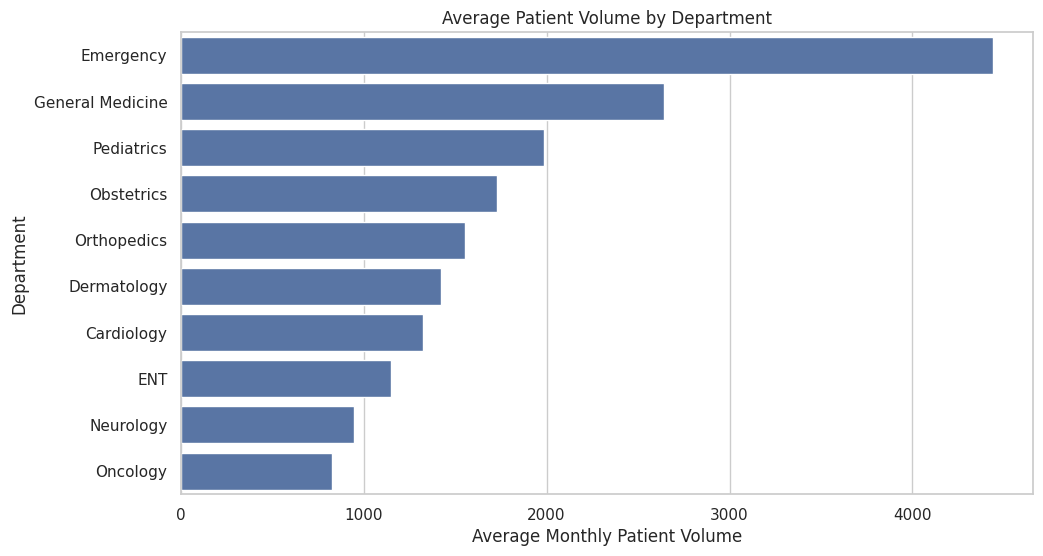

In [ ]:
# Patient volume by department
department_demand = (
    df_clean
    .groupby("Department")["Patient_Volume"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=department_demand.values,
    y=department_demand.index
)

plt.title("Average Patient Volume by Department")
plt.xlabel("Average Monthly Patient Volume")
plt.ylabel("Department")

plt.show()

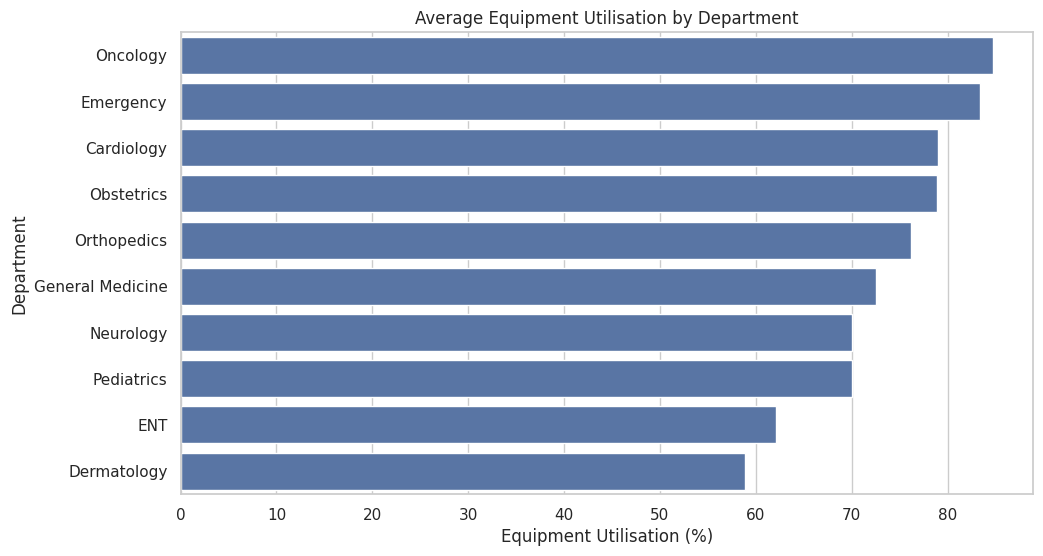

In [ ]:
# Equipment utilisation
utilisation_by_department = (
    df_clean
    .groupby("Department")["Equipment_Utilisation"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=utilisation_by_department.values,
    y=utilisation_by_department.index
)

plt.title("Average Equipment Utilisation by Department")
plt.xlabel("Equipment Utilisation (%)")
plt.ylabel("Department")

plt.show()

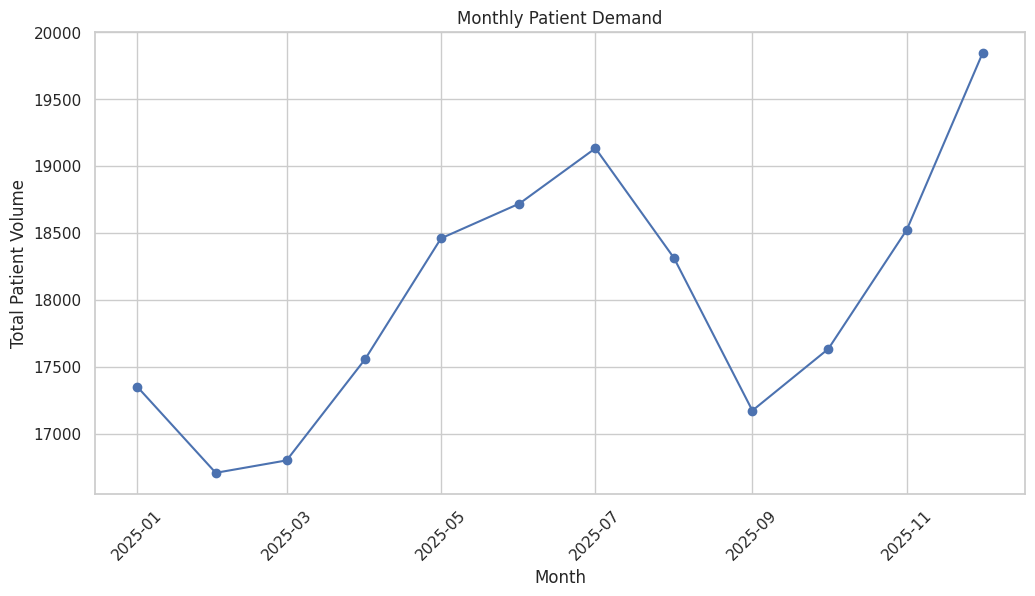

In [ ]:
# Monthly patient demand / seasonality
monthly_demand = (
    df_clean
    .groupby("Month")["Patient_Volume"]
    .sum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Monthly Patient Demand")
plt.xlabel("Month")
plt.ylabel("Total Patient Volume")

plt.xticks(rotation=45)

plt.show()

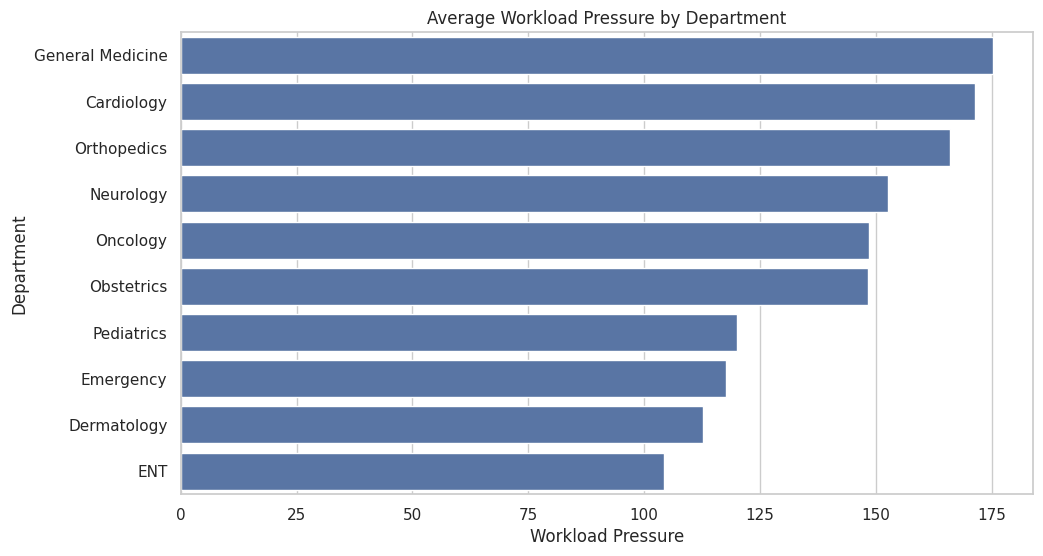

In [ ]:
# Workload pressure by department
workload_department = (
    df_clean
    .groupby("Department")[
        "Workload_Pressure_Calculated"
    ]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=workload_department.values,
    y=workload_department.index
)

plt.title("Average Workload Pressure by Department")
plt.xlabel("Workload Pressure")
plt.ylabel("Department")

plt.show()

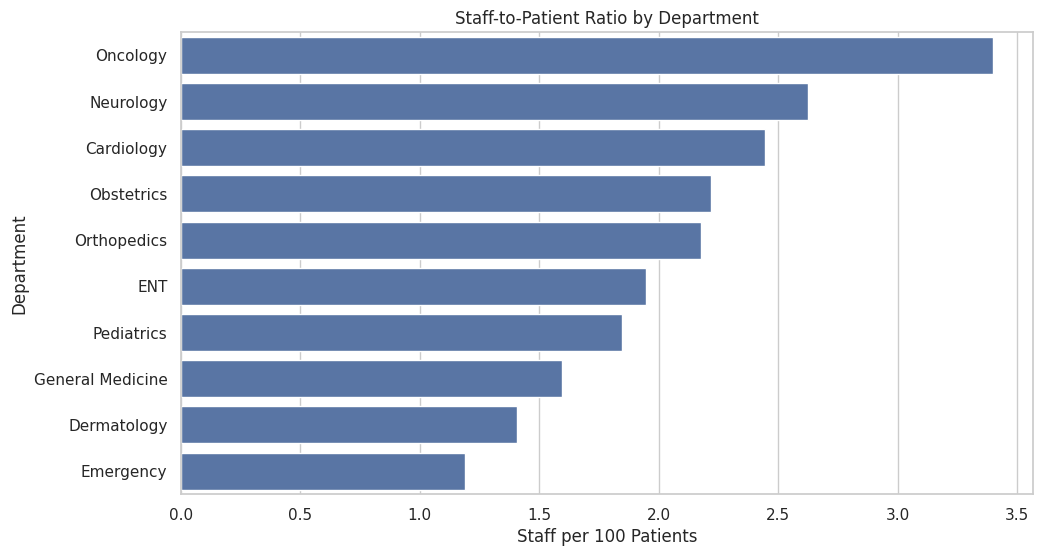

In [ ]:
# Staff-to-patient ratio
staff_ratio = (
    df_clean
    .groupby("Department")[
        "Staff_to_Patient_Ratio"
    ]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=staff_ratio.values,
    y=staff_ratio.index
)

plt.title("Staff-to-Patient Ratio by Department")
plt.xlabel("Staff per 100 Patients")
plt.ylabel("Department")

plt.show()

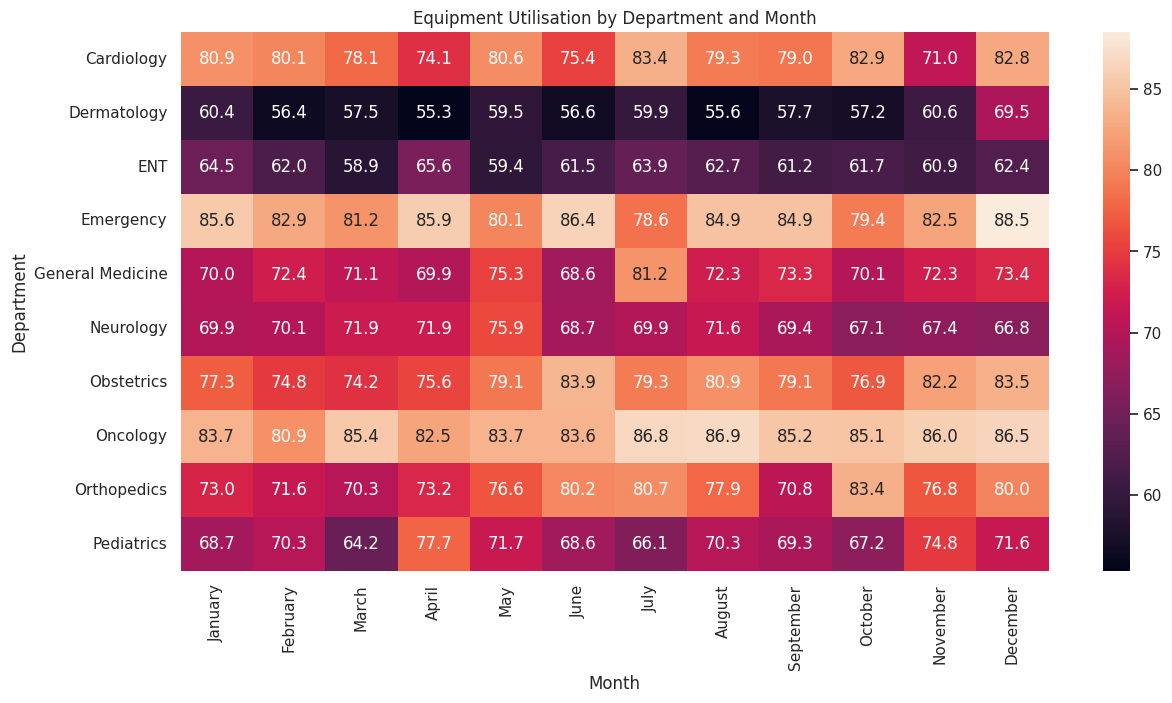

In [ ]:
# Department × utilisation heatmap
heatmap_data = df_clean.pivot_table(
    index="Department",
    columns="Month_Name",
    values="Equipment_Utilisation",
    aggfunc="mean"
)

month_order = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]

heatmap_data = heatmap_data.reindex(
    columns=[
        month for month in month_order
        if month in heatmap_data.columns
    ]
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title("Equipment Utilisation by Department and Month")
plt.xlabel("Month")
plt.ylabel("Department")

plt.show()

In [ ]:
# Identify consistently high utilisation
HIGH_UTILISATION_THRESHOLD = 75

high_utilisation = (
    df_clean["Equipment_Utilisation"]
    >= HIGH_UTILISATION_THRESHOLD
)

consistent_high = (
    df_clean.assign(
        High_Utilisation=high_utilisation
    )
    .groupby("Department")["High_Utilisation"]
    .agg(
        High_Utilisation_Months="sum",
        Total_Months="count"
    )
)

consistent_high["High_Utilisation_Percentage"] = (
    consistent_high["High_Utilisation_Months"]
    / consistent_high["Total_Months"]
    * 100
)

consistent_high = consistent_high.sort_values(
    "High_Utilisation_Percentage",
    ascending=False
)

display(consistent_high)

,High_Utilisation_Months,Total_Months,High_Utilisation_Percentage
Department,,,
Oncology,12,12,100.000000
Emergency,12,12,100.000000
Obstetrics,10,12,83.333333
Cardiology,10,12,83.333333
Orthopedics,7,12,58.333333
General Medicine,2,12,16.666667
Pediatrics,1,12,8.333333
Neurology,1,12,8.333333
Dermatology,0,12,0.000000


In [ ]:
consistently_high_departments = consistent_high[
    consistent_high["High_Utilisation_Months"] >= 8
]

print("Departments with consistently high utilisation:")

display(consistently_high_departments)

Departments with consistently high utilisation:


,High_Utilisation_Months,Total_Months,High_Utilisation_Percentage
Department,,,
Oncology,12,12,100.000000
Emergency,12,12,100.000000
Obstetrics,10,12,83.333333
Cardiology,10,12,83.333333


In [ ]:
# Resource utilisation significance test
department_groups = [
    group["Equipment_Utilisation"].dropna().values
    for _, group in df_clean.groupby("Department")
]

anova_stat, p_value = f_oneway(*department_groups)

print("ANOVA Test")
print("----------------------------")
print(f"F-statistic : {anova_stat:.4f}")
print(f"P-value     : {p_value:.6f}")

if p_value < 0.05:
    print(
        "\nResult: Equipment utilisation differs "
        "statistically between departments."
    )
else:
    print(
        "\nResult: No statistically significant "
        "difference detected between departments."
    )

ANOVA Test
----------------------------
F-statistic : 82.4386
P-value     : 0.000000

Result: Equipment utilisation differs statistically between departments.


In [ ]:
# Key data-driven insights
avg_patient_volume = (
    df_clean
    .groupby("Department")["Patient_Volume"]
    .mean()
)

avg_utilisation = (
    df_clean
    .groupby("Department")["Equipment_Utilisation"]
    .mean()
)

avg_workload = (
    df_clean
    .groupby("Department")[
        "Workload_Pressure_Calculated"
    ]
    .mean()
)

avg_staff_ratio = (
    df_clean
    .groupby("Department")[
        "Staff_to_Patient_Ratio"
    ].mean()
)

highest_demand_department = avg_patient_volume.idxmax()
highest_utilisation_department = avg_utilisation.idxmax()
highest_workload_department = avg_workload.idxmax()
lowest_staff_ratio_department = avg_staff_ratio.idxmin()

peak_month = monthly_demand.idxmax()
peak_month_value = monthly_demand.max()

print("KEY DATA-DRIVEN INSIGHTS")
print("=" * 50)

print(
    f"1. {highest_demand_department} has the highest "
    f"average monthly patient volume "
    f"({avg_patient_volume.max():.0f} patients)."
)

print(
    f"2. {highest_utilisation_department} has the highest "
    f"average equipment utilisation "
    f"({avg_utilisation.max():.2f}%)."
)

print(
    f"3. {highest_workload_department} has the highest "
    f"average workload pressure "
    f"({avg_workload.max():.2f})."
)

print(
    f"4. {lowest_staff_ratio_department} has the lowest "
    f"staff-to-patient ratio "
    f"({avg_staff_ratio.min():.2f} staff per 100 patients)."
)

print(
    f"5. {peak_month.strftime('%B %Y')} has the highest "
    f"total patient demand "
    f"({peak_month_value:.0f} patients)."
)

print(
    f"6. {len(consistently_high_departments)} department(s) "
    f"show consistently high equipment utilisation."
)

print(
    f"7. ANOVA p-value = {p_value:.6f}, indicating "
    f"{'a statistically significant' if p_value < 0.05 else 'no statistically significant'} "
    f"difference in utilisation between departments."
)

KEY DATA-DRIVEN INSIGHTS
1. Emergency has the highest average monthly patient volume (4438 patients).
2. Oncology has the highest average equipment utilisation (84.69%).
3. General Medicine has the highest average workload pressure (175.15).
4. Emergency has the lowest staff-to-patient ratio (1.19 staff per 100 patients).
5. December 2025 has the highest total patient demand (19845 patients).
6. 4 department(s) show consistently high equipment utilisation.
7. ANOVA p-value = 0.000000, indicating a statistically significant difference in utilisation between departments.


In [ ]:
# Random Forest
features = [
    "Patient_Volume",
    "Average_Treatment_Duration",
    "Staff_Count",
    "Equipment_Utilisation",
    "Month_Number",
    "Department"
]

target = "Resource_Status"

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 96
Testing samples: 24


In [ ]:
# Random Forest model
numeric_features = [
    "Patient_Volume",
    "Average_Treatment_Duration",
    "Staff_Count",
    "Equipment_Utilisation",
    "Month_Number"
]

categorical_features = [
    "Department"
]

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
# Model evaluation
y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("RANDOM FOREST MODEL EVALUATION")
print("=" * 40)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

RANDOM FOREST MODEL EVALUATION
Accuracy  : 0.9167
Precision : 0.9167
Recall    : 0.9167
F1 Score  : 0.9167


In [ ]:
# Classification report
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.80      0.80      0.80         5
    Moderate       0.83      0.83      0.83         6
      Normal       1.00      1.00      1.00        13

    accuracy                           0.92        24
   macro avg       0.88      0.88      0.88        24
weighted avg       0.92      0.92      0.92        24



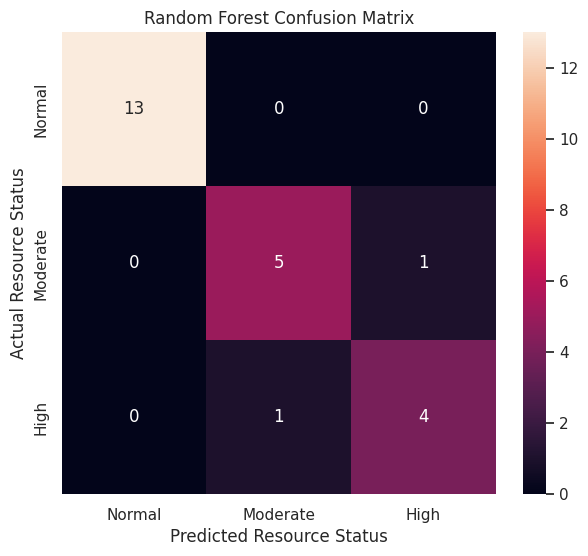

In [ ]:
# Confusion matrix
labels = [
    "Normal",
    "Moderate",
    "High"
]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Resource Status")
plt.ylabel("Actual Resource Status")

plt.show()

In [ ]:
# Feature importance
classifier = model.named_steps["classifier"]

preprocessor_fitted = (
    model.named_steps["preprocessor"]
)

encoded_features = (
    preprocessor_fitted
    .named_transformers_["categorical"]
    .named_steps["encoder"]
    .get_feature_names_out(
        categorical_features
    )
)

feature_names = (
    numeric_features +
    list(encoded_features)
)

importances = classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,Average_Treatment_Duration,0.243529
0,Patient_Volume,0.204448
3,Equipment_Utilisation,0.142716
2,Staff_Count,0.124224
4,Month_Number,0.122514
9,Department_General Medicine,0.029564
5,Department_Cardiology,0.027162
11,Department_Obstetrics,0.024191
14,Department_Pediatrics,0.019453
10,Department_Neurology,0.013443


In [ ]:
# Predict resource status
sample_department = pd.DataFrame({
    "Patient_Volume": [5000],
    "Average_Treatment_Duration": [1.5],
    "Staff_Count": [50],
    "Equipment_Utilisation": [90],
    "Month_Number": [12],
    "Department": ["Emergency"]
})

prediction = model.predict(
    sample_department
)

probability = model.predict_proba(
    sample_department
)

print("Predicted Resource Status:", prediction[0])

print("\nPrediction probabilities:")

for label, prob in zip(
    model.classes_,
    probability[0]
):
    print(f"{label}: {prob:.2%}")

Predicted Resource Status: Normal

Prediction probabilities:
High: 0.50%
Moderate: 0.50%
Normal: 99.00%


In [ ]:
# Practical resource allocation recommendation
department_summary = df_clean.groupby(
    "Department"
).agg(
    Avg_Patient_Volume=("Patient_Volume", "mean"),
    Avg_Equipment_Utilisation=(
        "Equipment_Utilisation",
        "mean"
    ),
    Avg_Workload_Pressure=(
        "Workload_Pressure_Calculated",
        "mean"
    ),
    Avg_Staff_Ratio=(
        "Staff_to_Patient_Ratio",
        "mean"
    )
).reset_index()

department_summary["Priority_Score"] = (
    department_summary["Avg_Workload_Pressure"].rank(
        pct=True
    ) * 0.40
    +
    department_summary[
        "Avg_Equipment_Utilisation"
    ].rank(pct=True) * 0.35
    +
    (
        1 -
        department_summary["Avg_Staff_Ratio"].rank(
            pct=True
        )
    ) * 0.25
)

department_summary = department_summary.sort_values(
    "Priority_Score",
    ascending=False
)

display(department_summary)

,Department,Avg_Patient_Volume,Avg_Equipment_Utilisation,Avg_Workload_Pressure,Avg_Staff_Ratio,Priority_Score
4,General Medicine,2640.416667,72.491667,175.147957,1.596079,0.750
0,Cardiology,1324.583333,78.966667,171.346150,2.442911,0.690
3,Emergency,4437.500000,83.408333,117.734698,1.188861,0.660
8,Orthopedics,1553.916667,76.208333,165.981965,2.174542,0.630
7,Oncology,825.166667,84.691667,148.525007,3.395848,0.590
6,Obstetrics,1728.833333,78.900000,148.382613,2.217733,0.520
5,Neurology,949.833333,70.050000,152.579644,2.625073,0.445
9,Pediatrics,1984.083333,70.041667,120.057235,1.847547,0.415
1,Dermatology,1423.666667,58.850000,112.753506,1.408556,0.315
2,ENT,1149.416667,62.058333,104.261825,1.944943,0.235


RESOURCE ALLOCATION ACTION PLAN

1. High-demand departments
   → Review staffing levels during peak-demand months.

2. Consistently high equipment utilisation
   → Consider equipment scheduling, maintenance planning,
     or additional capacity assessment.

3. High workload pressure
   → Prioritize staffing review and workload redistribution.

4. Low staff-to-patient ratio
   → Evaluate whether additional staff or shift redistribution
     is required.

5. Seasonal demand peaks
   → Prepare temporary staffing/resource plans before peak months.

6. Departments with persistent pressure
   → Conduct department-level capacity planning rather than
     relying only on historical assumptions.

7. Random Forest predictions
   → Use predictions as a decision-support signal, not as an
     automatic replacement for hospital management decisions.
     